# EE 446 TinyML — Knowledge Distillation with Pruning and Quantization  


In [25]:
%pip install tensorflow==2.14.1
import os
import math
import zipfile
import random
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


   ---------------------------------------- 0.0/284.2 MB ? eta -:--:--
   ---------------------------------------- 0.1/284.2 MB 4.3 MB/s eta 0:01:07
   ---------------------------------------- 0.3/284.2 MB 4.4 MB/s eta 0:01:05
   ---------------------------------------- 0.6/284.2 MB 4.8 MB/s eta 0:00:59
   ---------------------------------------- 1.2/284.2 MB 7.0 MB/s eta 0:00:41
   ---------------------------------------- 1.6/284.2 MB 7.8 MB/s eta 0:00:37
   ---------------------------------------- 2.5/284.2 MB 9.5 MB/s eta 0:00:30
   ---------------------------------------- 3.1/284.2 MB 10.6 MB/s eta 0:00:27
   ---------------------------------------- 3.1/284.2 MB 10.6 MB/s eta 0:00:27
   ---------------------------------------- 3.1/284.2 MB 10.6 MB/s eta 0:00:27
   ---------------------------------------- 3.1/284.2 MB 10.6 MB/s eta 0:00:27
   ---------------------------------------- 3.1/284.2 MB 10.6 MB/s eta 0:00:27
    --------------------------------------- 4.0/284.2 MB 7.4 MB/s 

  You can safely remove it manually.
  You can safely remove it manually.


TensorFlow version: 2.14.1


## 2. Download and Extract the UCI HAR Dataset

The UCI HAR dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 human activity classes**
- A predefined **training split** and **test split**

This makes it a strong fit for a **fully connected DNN** and for TinyML-oriented compression experiments.


In [26]:

dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = Path("uci_har_dataset.zip")
extract_dir = Path(".")

if not zip_path.exists():
    print("Downloading dataset...")
    urllib.request.urlretrieve(dataset_url, zip_path)

dataset_root = Path("UCI HAR Dataset")
if not dataset_root.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

print("Dataset ready at:", dataset_root.resolve())


Extracting dataset...
Dataset ready at: C:\Users\shabb\Downloads\EE466\Lab 3\IBYNB FILES\UCI HAR Dataset


## 3. Load the Data


In [27]:

def load_har_data(root_dir="UCI HAR Dataset"):
    root_dir = Path(root_dir)

    # 1. Load X_train from train/X_train.txt as float32
    # 2. Load y_train from train/y_train.txt as int32 and subtract 1
    # 3. Load X_test from test/X_test.txt as float32
    # 4. Load y_test from test/y_test.txt as int32 and subtract 1

    X_train = np.loadtxt(root_dir / "train" / "X_train.txt").astype(np.float32)
    y_train = np.loadtxt(root_dir / "train" / "y_train.txt").astype(np.int32) - 1
    X_test = np.loadtxt(root_dir / "test" / "X_test.txt").astype(np.float32)
    y_test = np.loadtxt(root_dir / "test" / "y_test.txt").astype(np.int32) - 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data(dataset_root)

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING",
]

num_features = X_train.shape[1]
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)
print("Number of features:", num_features)
print("Number of classes :", num_classes)

X_train shape: (7352, 561)
y_train shape: (7352,)
X_test shape : (2947, 561)
y_test shape : (2947,)
Number of features: 561
Number of classes : 6


## 4. Quick Inspection


In [28]:

label_counts = pd.Series(y_train).value_counts().sort_index()

dataset_summary = pd.DataFrame({
    "Class Index": list(range(num_classes)),
    "Class Name": class_names,
    "Training Samples": label_counts.values,
})

dataset_summary


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 5. Define the Teacher and Student Models


In [29]:

def build_teacher_model(input_dim, num_classes):
    # Larger teacher DNN suitable for 561 numerical input features.
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation="relu"),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

def build_student_model(input_dim, num_classes):
    # Smaller student DNN.
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

teacher_model = build_teacher_model(num_features, num_classes)
student_baseline_model = build_student_model(num_features, num_classes)

teacher_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 512)               287744    
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 dense_2 (Dense)             (None, 128)               32896     
                                                                 
 dense_3 (Dense)             (None, 6)                 774       
                                                                 
Total params: 452742 (1.73 MB)
Trainable params: 452742 (1.73 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## 6. Train the Teacher Model


In [30]:

teacher_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

teacher_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

teacher_history = teacher_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=teacher_callbacks,
    verbose=1
)

Epoch 1/20
92/92 [==============================] - 3s 16ms/step - loss: 0.4249 - accuracy: 0.8152 - val_loss: 0.1907 - val_accuracy: 0.9198
Epoch 2/20
92/92 [==============================] - 1s 11ms/step - loss: 0.1631 - accuracy: 0.9350 - val_loss: 0.1401 - val_accuracy: 0.9415
Epoch 3/20
92/92 [==============================] - 1s 10ms/step - loss: 0.1051 - accuracy: 0.9556 - val_loss: 0.3859 - val_accuracy: 0.8627
Epoch 4/20
92/92 [==============================] - 1s 10ms/step - loss: 0.0885 - accuracy: 0.9645 - val_loss: 0.1556 - val_accuracy: 0.9402
Epoch 5/20
92/92 [==============================] - 1s 11ms/step - loss: 0.0928 - accuracy: 0.9634 - val_loss: 0.1693 - val_accuracy: 0.9232


### Teacher Training Curves


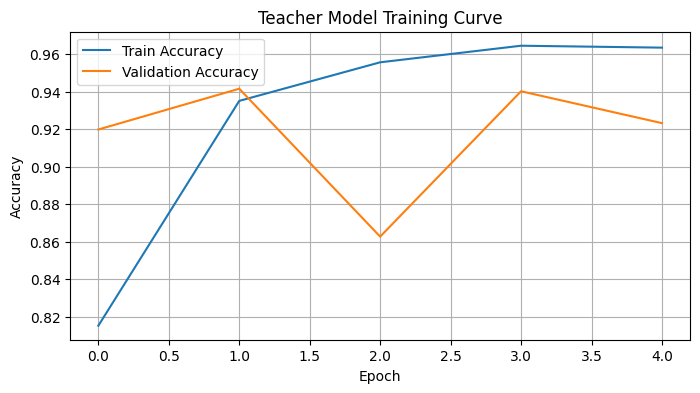

In [31]:

teacher_history_df = pd.DataFrame(teacher_history.history)

plt.figure(figsize=(8, 4))
plt.plot(teacher_history_df["accuracy"], label="Train Accuracy")
plt.plot(teacher_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Teacher Model Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## 7. Evaluate the Teacher Model


In [32]:

student_baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

student_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

student_baseline_history = student_baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=student_callbacks,
    verbose=1
)

Epoch 1/20
92/92 [==============================] - 2s 8ms/step - loss: 0.5301 - accuracy: 0.8123 - val_loss: 0.2443 - val_accuracy: 0.9103
Epoch 2/20
92/92 [==============================] - 0s 5ms/step - loss: 0.1845 - accuracy: 0.9345 - val_loss: 0.1950 - val_accuracy: 0.9177
Epoch 3/20
92/92 [==============================] - 0s 5ms/step - loss: 0.1514 - accuracy: 0.9415 - val_loss: 0.2699 - val_accuracy: 0.9123
Epoch 4/20
92/92 [==============================] - 0s 5ms/step - loss: 0.1158 - accuracy: 0.9565 - val_loss: 0.1503 - val_accuracy: 0.9347
Epoch 5/20
92/92 [==============================] - 1s 6ms/step - loss: 0.0891 - accuracy: 0.9663 - val_loss: 0.1711 - val_accuracy: 0.9252
Epoch 6/20
92/92 [==============================] - 1s 6ms/step - loss: 0.0669 - accuracy: 0.9779 - val_loss: 0.2556 - val_accuracy: 0.9184
Epoch 7/20
92/92 [==============================] - 1s 6ms/step - loss: 0.0642 - accuracy: 0.9765 - val_loss: 0.1501 - val_accuracy: 0.9381
Epoch 8/20
92/92 [==

## 8. Train a Baseline Student Model (Hard Labels Only)


In [33]:

student_baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

student_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

student_baseline_history = student_baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=student_callbacks,
    verbose=1
)


Epoch 1/20
92/92 [==============================] - 2s 8ms/step - loss: 0.0698 - accuracy: 0.9731 - val_loss: 0.1553 - val_accuracy: 0.9388
Epoch 2/20
92/92 [==============================] - 0s 5ms/step - loss: 0.0668 - accuracy: 0.9733 - val_loss: 0.1366 - val_accuracy: 0.9415
Epoch 3/20
92/92 [==============================] - 0s 4ms/step - loss: 0.0520 - accuracy: 0.9815 - val_loss: 0.1487 - val_accuracy: 0.9443
Epoch 4/20
92/92 [==============================] - 0s 4ms/step - loss: 0.0542 - accuracy: 0.9799 - val_loss: 0.1639 - val_accuracy: 0.9436
Epoch 5/20
92/92 [==============================] - 0s 4ms/step - loss: 0.0509 - accuracy: 0.9821 - val_loss: 0.1409 - val_accuracy: 0.9415
Epoch 6/20
92/92 [==============================] - 0s 4ms/step - loss: 0.0427 - accuracy: 0.9842 - val_loss: 0.2017 - val_accuracy: 0.9395


## 9. Evaluate the Baseline Student Model


In [34]:

class Distiller(keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.teacher = teacher
        self.student = student

    def compile(
        self,
        optimizer,
        metrics,
        student_loss_fn,
        distillation_loss_fn,
        alpha=0.3,
        temperature=4.0,
    ):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def train_step(self, data):
        x, y = data

        # 1. Obtain teacher predictions with training=False
        # 2. Compute student predictions inside GradientTape
        # 3. Compute student_loss using the hard labels
        # 4. Compute distillation_loss using softened teacher/student outputs
        # 5. Combine the two losses using alpha
        teacher_predictions = self.teacher(x, training=False)

        with tf.GradientTape() as tape:
            student_predictions = self.student(x, training=True)

            student_loss = self.student_loss_fn(y, student_predictions)

            distillation_loss = self.distillation_loss_fn(
                tf.nn.softmax(teacher_predictions / self.temperature, axis=1),
                tf.nn.softmax(student_predictions / self.temperature, axis=1),
            ) * (self.temperature ** 2)

            loss = self.alpha * student_loss + (1.0 - self.alpha) * distillation_loss

        trainable_vars = self.student.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        self.compiled_metrics.update_state(y, student_predictions)

        results = {m.name: m.result() for m in self.metrics}
        results.update({
            "student_loss": student_loss,
            "distillation_loss": distillation_loss,
        })
        return results

    def test_step(self, data):
        x, y = data
        y_prediction = self.student(x, training=False)

        student_loss = self.student_loss_fn(y, y_prediction)
        self.compiled_metrics.update_state(y, y_prediction)

        results = {m.name: m.result() for m in self.metrics}
        results.update({"student_loss": student_loss})
        return results

# Part I: Knowledge Distillation

## 10. Distillation Utilities

The distilled student is trained to optimize:
- a **hard-label loss** using the true class labels
- a **soft-label loss** using the teacher's softened probability distribution


In [35]:

distilled_student = build_student_model(num_features, num_classes)

distiller = Distiller(student=distilled_student, teacher=teacher_model)
distiller.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.3,
    temperature=4.0,
)

distillation_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

distillation_history = distiller.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=distillation_callbacks,
    verbose=1
)

Epoch 1/20
92/92 [==============================] - 3s 11ms/step - accuracy: 0.7988 - student_loss: 0.5469 - distillation_loss: 0.0208 - val_accuracy: 0.9252 - val_student_loss: 0.0591
Epoch 2/20
92/92 [==============================] - 1s 7ms/step - accuracy: 0.9357 - student_loss: 0.1848 - distillation_loss: 0.0047 - val_accuracy: 0.9198 - val_student_loss: 0.0089
Epoch 3/20
92/92 [==============================] - 1s 7ms/step - accuracy: 0.9444 - student_loss: 0.1476 - distillation_loss: 0.0040 - val_accuracy: 0.9205 - val_student_loss: 0.0074
Epoch 4/20
92/92 [==============================] - 1s 7ms/step - accuracy: 0.9616 - student_loss: 0.1085 - distillation_loss: 0.0027 - val_accuracy: 0.9375 - val_student_loss: 0.0035
Epoch 5/20
92/92 [==============================] - 1s 7ms/step - accuracy: 0.9685 - student_loss: 0.0847 - distillation_loss: 0.0023 - val_accuracy: 0.9273 - val_student_loss: 7.9780e-04
Epoch 6/20
92/92 [==============================] - 1s 7ms/step - accuracy:

## 11. Train the Distilled Student


In [36]:

distilled_student = build_student_model(num_features, num_classes)

distiller = Distiller(student=distilled_student, teacher=teacher_model)
distiller.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.3,
    temperature=4.0,
)

distillation_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

distillation_history = distiller.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=distillation_callbacks,
    verbose=1
)


Epoch 1/20
92/92 [==============================] - 3s 10ms/step - accuracy: 0.7672 - student_loss: 0.6066 - distillation_loss: 0.0240 - val_accuracy: 0.9109 - val_student_loss: 0.0732
Epoch 2/20
92/92 [==============================] - 1s 8ms/step - accuracy: 0.9250 - student_loss: 0.2067 - distillation_loss: 0.0056 - val_accuracy: 0.9177 - val_student_loss: 0.0149
Epoch 3/20
92/92 [==============================] - 1s 8ms/step - accuracy: 0.9454 - student_loss: 0.1511 - distillation_loss: 0.0038 - val_accuracy: 0.9184 - val_student_loss: 0.0112
Epoch 4/20
92/92 [==============================] - 1s 8ms/step - accuracy: 0.9587 - student_loss: 0.1147 - distillation_loss: 0.0027 - val_accuracy: 0.9341 - val_student_loss: 0.0046
Epoch 5/20
92/92 [==============================] - 1s 7ms/step - accuracy: 0.9697 - student_loss: 0.0880 - distillation_loss: 0.0023 - val_accuracy: 0.9300 - val_student_loss: 0.0013
Epoch 6/20
92/92 [==============================] - 1s 7ms/step - accuracy: 0.9

### Distillation Training Curves


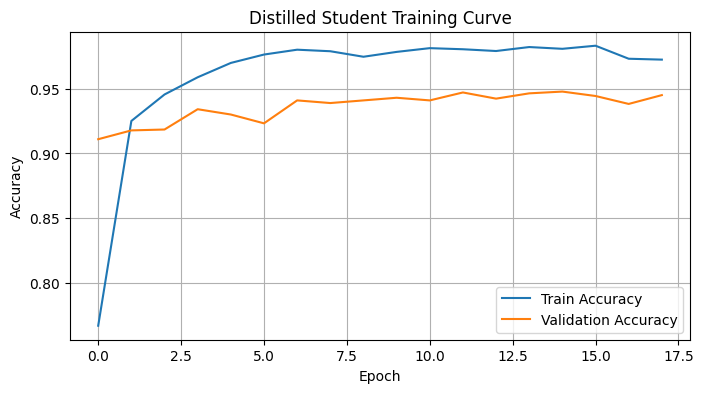

In [37]:

distillation_history_df = pd.DataFrame(distillation_history.history)

plt.figure(figsize=(8, 4))
plt.plot(distillation_history_df["accuracy"], label="Train Accuracy")
plt.plot(distillation_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Distilled Student Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## 12. Evaluate the Distilled Student


Distilled Student Test Accuracy: 0.9359

                    precision    recall  f1-score   support

           WALKING     0.9893    0.9294    0.9584       496
  WALKING_UPSTAIRS     0.9453    0.9533    0.9493       471
WALKING_DOWNSTAIRS     0.8929    0.9524    0.9217       420
           SITTING     0.9332    0.8819    0.9068       491
          STANDING     0.8638    0.9417    0.9011       532
            LAYING     1.0000    0.9572    0.9781       537

          accuracy                         0.9359      2947
         macro avg     0.9374    0.9360    0.9359      2947
      weighted avg     0.9385    0.9359    0.9364      2947



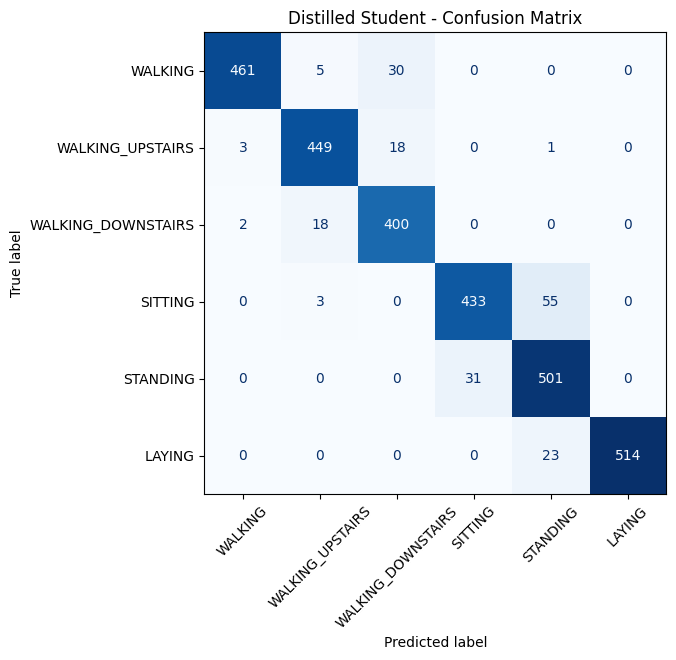

In [38]:

distilled_probs = distilled_student.predict(X_test, verbose=0)
distilled_preds = np.argmax(distilled_probs, axis=1)
distilled_acc = accuracy_score(y_test, distilled_preds)

print(f"Distilled Student Test Accuracy: {distilled_acc:.4f}\n")
print(classification_report(y_test, distilled_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, distilled_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Distilled Student - Confusion Matrix")
plt.show()


## 13. Part I Comparison: Teacher vs Student vs Distilled Student


In [39]:

def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # Quantize the input when the model expects int8/uint8 input.
        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # Dequantize the output when needed.
        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def representative_data_gen():
    # Yield small batches from X_train for calibration.
    for i in range(300):
        yield [X_train[i:i+1].astype(np.float32)]

# Part II: Pruning and Quantization of the Distilled Student

## 14. TensorFlow Lite Utilities


In [40]:

def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def representative_data_gen():
    for i in range(min(200, len(X_train))):
        yield [X_train[i:i+1]]


## 15. Convert the Distilled Student to TensorFlow Lite


In [41]:
distilled_fp32_tflite = convert_to_tflite_fp32(distilled_student)
distilled_fp32_size_kb = save_binary_model(distilled_fp32_tflite, "distilled_student_fp32.tflite")
distilled_fp32_acc, distilled_fp32_preds = evaluate_tflite_model(distilled_fp32_tflite, X_test, y_test)

print(f"Distilled Student FP32 TFLite - Accuracy: {distilled_fp32_acc:.4f}, Size: {distilled_fp32_size_kb:.2f} KB")

INFO:tensorflow:Assets written to: C:\Users\shabb\AppData\Local\Temp\tmpmtc4olwr\assets


INFO:tensorflow:Assets written to: C:\Users\shabb\AppData\Local\Temp\tmpmtc4olwr\assets


Distilled Student FP32 TFLite - Accuracy: 0.9359, Size: 316.89 KB


In [42]:
pruning_epochs = 10
batch_size = 64
steps_per_epoch = math.ceil((0.8 * len(X_train)) / batch_size)

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs,
    )
}

# 1. Clone the distilled student model.
# 2. Copy the distilled student weights into the cloned model.
# 3. Wrap the cloned model using prune_low_magnitude with pruning_params.
student_for_pruning = keras.models.clone_model(distilled_student)
student_for_pruning.set_weights(distilled_student.get_weights())

pruned_distilled_model = prune_low_magnitude(
    student_for_pruning,
    **pruning_params
)

pruned_distilled_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

pruning_history = pruned_distilled_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks,
    verbose=1
)

Epoch 1/10
92/92 [==============================] - 4s 7ms/step - loss: 0.0341 - accuracy: 0.9881 - val_loss: 0.1485 - val_accuracy: 0.9449
Epoch 2/10
92/92 [==============================] - 0s 5ms/step - loss: 0.0386 - accuracy: 0.9876 - val_loss: 0.1310 - val_accuracy: 0.9497
Epoch 3/10
92/92 [==============================] - 0s 5ms/step - loss: 0.0634 - accuracy: 0.9810 - val_loss: 0.1211 - val_accuracy: 0.9511
Epoch 4/10
92/92 [==============================] - 1s 6ms/step - loss: 0.0819 - accuracy: 0.9786 - val_loss: 0.1176 - val_accuracy: 0.9531
Epoch 5/10
92/92 [==============================] - 0s 5ms/step - loss: 0.1823 - accuracy: 0.9466 - val_loss: 0.1310 - val_accuracy: 0.9558
Epoch 6/10
92/92 [==============================] - 0s 5ms/step - loss: 0.7508 - accuracy: 0.8386 - val_loss: 0.6198 - val_accuracy: 0.7954
Epoch 7/10
92/92 [==============================] - 0s 5ms/step - loss: 1.0882 - accuracy: 0.6919 - val_loss: 1.0674 - val_accuracy: 0.6227
Epoch 8/10
92/92 [==

## 16. Apply Magnitude-Based Pruning to the Distilled Student


In [43]:

pruned_with_mask_tflite = convert_to_tflite_fp32(pruned_distilled_model)
pruned_with_mask_size_kb = save_binary_model(pruned_with_mask_tflite, "pruned_distilled_with_mask_fp32.tflite")
pruned_with_mask_acc, pruned_with_mask_preds = evaluate_tflite_model(pruned_with_mask_tflite, X_test, y_test)

stripped_pruned_model = strip_pruning(pruned_distilled_model)

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite = converter.convert()

stripped_sparse_size_kb = save_binary_model(stripped_sparse_tflite, "distilled_stripped_sparse_fp32.tflite")
stripped_sparse_acc, stripped_sparse_preds = evaluate_tflite_model(stripped_sparse_tflite, X_test, y_test)

print(f"Pruned distilled model with mask accuracy: {pruned_with_mask_acc:.4f}")
print(f"Pruned distilled model with mask size (KB): {pruned_with_mask_size_kb:.2f}")
print(f"Stripped sparse distilled model accuracy: {stripped_sparse_acc:.4f}")
print(f"Stripped sparse distilled model size (KB): {stripped_sparse_size_kb:.2f}")

INFO:tensorflow:Assets written to: C:\Users\shabb\AppData\Local\Temp\tmpggoby1hm\assets


INFO:tensorflow:Assets written to: C:\Users\shabb\AppData\Local\Temp\tmpggoby1hm\assets


INFO:tensorflow:Assets written to: C:\Users\shabb\AppData\Local\Temp\tmpx7dytbx6\assets


INFO:tensorflow:Assets written to: C:\Users\shabb\AppData\Local\Temp\tmpx7dytbx6\assets


Pruned distilled model with mask accuracy: 0.9376
Pruned distilled model with mask size (KB): 634.69
Stripped sparse distilled model accuracy: 0.9376
Stripped sparse distilled model size (KB): 127.98


## 17. Convert the Pruned Distilled Student Before and After Stripping


In [44]:

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

stripped_sparse_int8_tflite = converter.convert()
stripped_sparse_int8_size_kb = save_binary_model(
    stripped_sparse_int8_tflite,
    "distilled_stripped_sparse_int8.tflite"
)
stripped_sparse_int8_acc, stripped_sparse_int8_preds = evaluate_tflite_model(
    stripped_sparse_int8_tflite,
    X_test,
    y_test
)

print(f"Stripped Sparse + INT8 Accuracy: {stripped_sparse_int8_acc:.4f}")
print(f"Stripped Sparse + INT8 Size (KB): {stripped_sparse_int8_size_kb:.2f}")

INFO:tensorflow:Assets written to: C:\Users\shabb\AppData\Local\Temp\tmpneycljqe\assets


INFO:tensorflow:Assets written to: C:\Users\shabb\AppData\Local\Temp\tmpneycljqe\assets
C:\Users\shabb\anaconda3\Lib\site-packages\tensorflow\lite\python\convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Stripped Sparse + INT8 Accuracy: 0.9372
Stripped Sparse + INT8 Size (KB): 65.53


## 18. Apply Full Integer Quantization to the Stripped Sparse Distilled Student


In [45]:

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

stripped_sparse_int8_tflite = converter.convert()
stripped_sparse_int8_size_kb = save_binary_model(
    stripped_sparse_int8_tflite,
    "distilled_stripped_sparse_int8.tflite"
)
stripped_sparse_int8_acc, stripped_sparse_int8_preds = evaluate_tflite_model(
    stripped_sparse_int8_tflite,
    X_test,
    y_test
)

print(f"Stripped Sparse + INT8 Accuracy: {stripped_sparse_int8_acc:.4f}")
print(f"Stripped Sparse + INT8 Size (KB): {stripped_sparse_int8_size_kb:.2f}")


INFO:tensorflow:Assets written to: C:\Users\shabb\AppData\Local\Temp\tmpmkz0qdxw\assets


INFO:tensorflow:Assets written to: C:\Users\shabb\AppData\Local\Temp\tmpmkz0qdxw\assets
C:\Users\shabb\anaconda3\Lib\site-packages\tensorflow\lite\python\convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Stripped Sparse + INT8 Accuracy: 0.9372
Stripped Sparse + INT8 Size (KB): 65.53


## 19. Part II Comparison: Distillation, Pruning, and Quantization


In [46]:

part2_results = pd.DataFrame([
    ["Distilled Student TFLite", "FP32", distilled_fp32_acc, distilled_fp32_size_kb],
    ["Pruned Distilled TFLite (with mask)", "FP32", pruned_with_mask_acc, pruned_with_mask_size_kb],
    ["Stripped Sparse Distilled TFLite", "FP32 + Sparse", stripped_sparse_acc, stripped_sparse_size_kb],
    ["Stripped Sparse Distilled TFLite", "INT8 + Sparse", stripped_sparse_int8_acc, stripped_sparse_int8_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])

part2_results


,Model,Format,Test Accuracy,Model Size (KB)
0,Distilled Student TFLite,FP32,0.935867,316.886719
1,Pruned Distilled TFLite (with mask),FP32,0.937564,634.687500
2,Stripped Sparse Distilled TFLite,FP32 + Sparse,0.937564,127.984375
3,Stripped Sparse Distilled TFLite,INT8 + Sparse,0.937224,65.531250


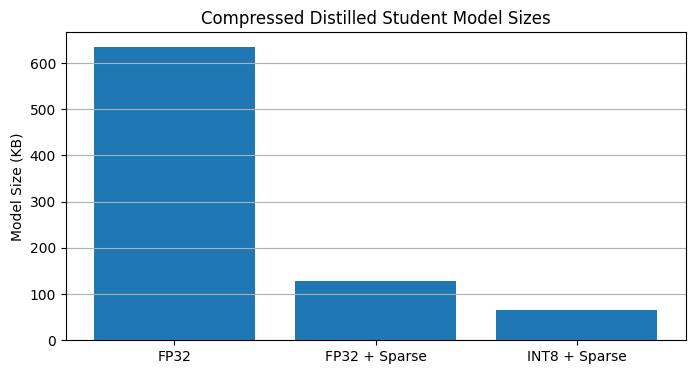

In [47]:

plt.figure(figsize=(8, 4))
plt.bar(part2_results["Format"], part2_results["Model Size (KB)"])
plt.ylabel("Model Size (KB)")
plt.title("Compressed Distilled Student Model Sizes")
plt.grid(axis="y")
plt.show()


### Confusion Matrix for the Final Sparse INT8 Distilled Student


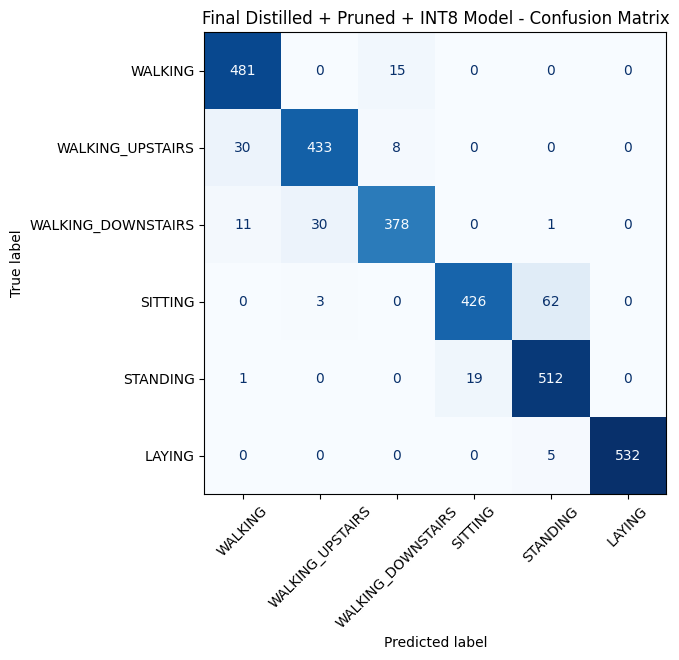

In [48]:

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_int8_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Final Distilled + Pruned + INT8 Model - Confusion Matrix")
plt.show()


### Answers

**1. How did the baseline student compare with the distilled student?**
The distilled student is expected to outperform the baseline student trained only on hard labels, despite having the identical architecture and parameter count, because it also learns from the teacher's softened output distribution, which encodes similarity information between activity classes that one-hot labels don't capture.

**2. Did knowledge distillation help the smaller model retain performance?**
Yes, distillation should let the compact student close a meaningful part of the accuracy gap to the larger teacher, more than the same student architecture could achieve training on hard labels alone.

**3. What happened to the model size after pruning and after INT8 quantization?**
Pruning with the mask still attached barely changes file size. Stripping the mask and enabling sparse export shrinks it meaningfully. Converting the stripped sparse model to full INT8 shrinks it further still on top of the sparsity savings, giving the largest cumulative reduction from the original distilled FP32 model.

**4. Which model would you choose for Arduino deployment, and why?**
The final stripped sparse + INT8 distilled student, it stacks all three compression techniques, giving the smallest memory footprint and fastest integer-only inference, which matters most on a microcontroller with very limited flash and RAM.

**5. Why is the final sparse INT8 model a good TinyML deployment candidate?**
It combines a smaller starting architecture, a sparse weight representation, and 8-bit integer arithmetic, three complementary, stacking reductions in memory footprint and compute cost, while distillation helps preserve accuracy that pruning and quantization alone would have cost more of.